# 05 · Análisis final e integración
Cierre del insight: combinamos el modelo de **tono** (supervisado) con el de **tema** (no supervisado) en una vista accionable para la agencia de marketing.

In [2]:
# === Setup reproducible (Google Colab) ===

import sys, os, subprocess, glob
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

hits = glob.glob("/content/drive/MyDrive/**/src/config.py", recursive=True)
if not hits:
    raise FileNotFoundError(
        "No se encontro src/config.py en tu Drive. Verifica que subiste "
        "la carpeta completa del proyecto (con la carpeta src/ y sus .py)."
    )
root = Path(hits[0]).parent.parent
os.environ["PROJECT_ROOT"] = str(root)
sys.path.insert(0, str(root / "src"))

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"],
               check=False)

from config import set_global_seed, ensure_dirs, SEED
set_global_seed(SEED)   # fija todas las semillas
ensure_dirs()           # crea carpetas de salida
print(f"Entorno listo. Raiz del proyecto: {root} | SEED={SEED}")

Mounted at /content/drive
Entorno listo. Raiz del proyecto: /content/drive/MyDrive/Ev2 Program Ciencia datos  | SEED=42


In [3]:
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt, seaborn as sns
from data_preprocessing import load_dataset
from model_training import build_text_features
from sklearn.cluster import KMeans
from config import MODELS_DIR, PLOTS_DIR

df = load_dataset()
model = joblib.load(MODELS_DIR / 'best_supervised_tuned.joblib')

## 1. Pipeline integrado: tono + tema
Para cada post predecimos el tono y le asignamos su tema (cluster).

In [4]:
df = df.copy()
df['tono_pred'] = model.predict(df['text_content'].fillna(''))
feat = build_text_features()
Xr = feat.fit_transform(df['text_content'].fillna(''))
df['tema'] = KMeans(n_clusters=6, random_state=SEED, n_init=10).fit_predict(Xr)
df[['text_content','tono_pred','tema']].head()

,text_content,tono_pred,tema
0,Just tried the Chromebook from Google. Best pu...,Positive,1
1,Just saw an ad for Microsoft Surface Laptop du...,Negative,2
2,What's your opinion about Nike's Epic React? ...,Negative,1
3,Bummed out with my new Diet Pepsi from Pepsi! ...,Negative,3
4,Just tried the Corolla from Toyota. Absolutely...,Positive,1


## 2. Matriz accionable: tema × tono
Dónde se concentra el descontento. Esta es la salida de negocio del proyecto.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

df = df.copy()
df['tono_pred'] = model.predict(df['text_content'].fillna(''))

# Clustering sobre TF-IDF (permite leer los terminos de cada cluster)
vec_tema = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words='english')
Xtema = vec_tema.fit_transform(df['text_content'].fillna(''))
km = KMeans(n_clusters=6, random_state=SEED, n_init=10).fit(Xtema)
df['tema'] = km.labels_

# Terminos top de cada cluster para entender de que habla
terminos = np.array(vec_tema.get_feature_names_out())
orden = km.cluster_centers_.argsort()[:, ::-1]
print("Terminos principales por cluster:")
for i in range(6):
    print(f"  Cluster {i}: " + ", ".join(terminos[orden[i, :6]]))

# Nombres descriptivos segun la intencion del post (derivados de los terminos)
NOMBRES_TEMA = {
    0: 'Experiencia producto nuevo',
    1: 'Pide opinion',
    2: 'Reaccion a publicidad',
    3: 'Pide feedback',
    4: 'Eventos',
    5: 'Invita a comentar',
}
df['tema_nombre'] = df['tema'].map(NOMBRES_TEMA)
df[['text_content', 'tono_pred', 'tema', 'tema_nombre']].head()

Terminos principales por cluster:
  Cluster 0: ad, saw ad, saw, just saw, just, ad samsung
  Cluster 1: know think, let know, know, think, let, wait
  Cluster 2: feedback, love feedback, love, wait coming, wait, coming
  Cluster 3: pepsi, pepsi pepsi, pepsi max, new pepsi, zero sugar, sugar
  Cluster 4: experience, curious, curious experience, new, experienced, unboxed
  Cluster 5: interested hearing, interested, really interested, really, hearing, thoughts


,text_content,tono_pred,tema,tema_nombre
0,Just tried the Chromebook from Google. Best pu...,Positive,5,Invita a comentar
1,Just saw an ad for Microsoft Surface Laptop du...,Negative,0,Experiencia producto nuevo
2,What's your opinion about Nike's Epic React? ...,Negative,5,Invita a comentar
3,Bummed out with my new Diet Pepsi from Pepsi! ...,Negative,3,Pide feedback
4,Just tried the Corolla from Toyota. Absolutely...,Positive,5,Invita a comentar


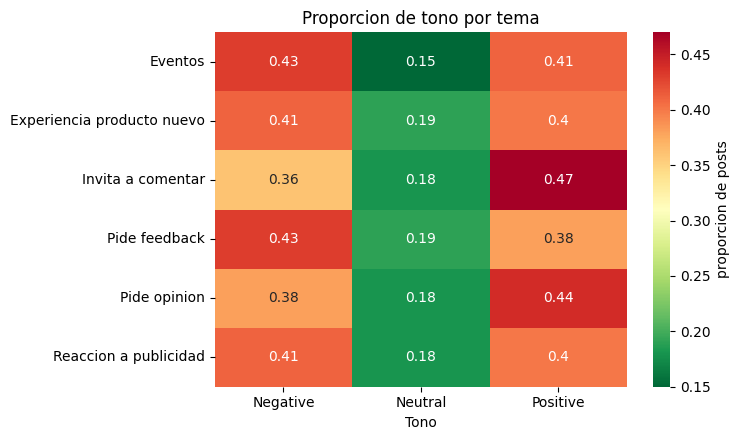

tono_pred,Negative,Neutral,Positive
tema_nombre,,,
Eventos,0.43,0.15,0.41
Experiencia producto nuevo,0.41,0.19,0.40
Invita a comentar,0.36,0.18,0.47
Pide feedback,0.43,0.19,0.38
Pide opinion,0.38,0.18,0.44
Reaccion a publicidad,0.41,0.18,0.40


In [7]:
# Matriz tema (con nombre) x tono. normalize='index' -> cada fila suma 1
matriz = pd.crosstab(df['tema_nombre'], df['tono_pred'], normalize='index').round(2)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.heatmap(matriz, annot=True, cmap='RdYlGn_r', ax=ax,
            cbar_kws={'label': 'proporcion de posts'})
ax.set_title('Proporcion de tono por tema'); ax.set_xlabel('Tono'); ax.set_ylabel('')
plt.tight_layout(); plt.savefig(PLOTS_DIR / 'tema_x_tono.png', dpi=130); plt.show()
matriz

## 3. Recomendaciones para la agencia
- **Monitor de reputación:** el clasificador (F1≈0.94) etiqueta el flujo de posts en tiempo real y dispara alertas cuando sube el % de tono negativo.
- **Foco de acción:** la matriz tema×tono indica *dónde* intervenir (qué tema concentra el descontento), no solo *cuánto*.
- **Modelo elegido:** Regresión Logística por rapidez e interpretabilidad — permite explicar al cliente *qué palabras* dispararon una alerta.
- **Limitación documentada:** `engagement_rate` no es predecible honestamente (sin señal / leakage); no se debe prometer su predicción al cliente.

**Fin del pipeline.** Notebooks 01→05 reproducibles con `SEED=42`. Resultados en `results/`, modelos en `models/trained_models/`.